In [6]:
import pandas as pd

print("🔧 Reparando el cruce de ELO con fechas inexactas...")

# 1. Cargar el dataset de partidos con clima y el ELO original desde tu Drive
df_clima = pd.read_csv('/content/drive/MyDrive/IESGranCapitan/futbol/SP1_con_clima.csv', sep=',')
df_elo = pd.read_csv('/content/drive/MyDrive/IESGranCapitan/futbol/EloSP1.csv', sep=';')

# 2. Convertir a formato fecha real de Pandas y ORDENAR (Vital para el merge_asof)
df_clima['Date'] = pd.to_datetime(df_clima['Date'], format="%d/%m/%Y")
df_clima = df_clima.sort_values('Date')

df_elo['date'] = pd.to_datetime(df_elo['date'], format="%d/%m/%Y")
df_elo = df_elo.sort_values('date')

# 3. Cruce Inteligente (Hacia atrás en el tiempo) para el Equipo LOCAL
df_final = pd.merge_asof(
    df_clima,
    df_elo[['date', 'club', 'elo']].rename(columns={'elo': 'elo_local'}),
    left_on='Date', right_on='date', left_by='HomeTeam', right_by='club',
    direction='backward'
).drop(columns=['date', 'club'])

# 4. Cruce Inteligente para el Equipo VISITANTE
df_final = pd.merge_asof(
    df_final,
    df_elo[['date', 'club', 'elo']].rename(columns={'elo': 'elo_visitante'}),
    left_on='Date', right_on='date', left_by='AwayTeam', right_by='club',
    direction='backward'
).drop(columns=['date', 'club'])

# 5. Calcular métricas finales y estandarizar
df_final['elo_local'] = df_final['elo_local'] / 100.0
df_final['elo_visitante'] = df_final['elo_visitante'] / 100.0
df_final['dif_elo'] = df_final['elo_local'] - df_final['elo_visitante']

# Volver a poner la fecha en su formato legible
df_final['Date'] = df_final['Date'].dt.strftime("%d/%m/%Y")

# Guardar la versión reparada sobrescribiendo el archivo anterior
ruta_final = '/content/drive/MyDrive/IESGranCapitan/futbol/LaLiga_Dataset_Final.csv'
df_final.to_csv(ruta_final, sep=",", index=False)

print(f"✅ ¡Reparación completada! El ELO ahora cubre a {df_final['dif_elo'].notna().sum()} partidos (todos los jugados a partir del año 2000).")

🔧 Reparando el cruce de ELO con fechas inexactas...
✅ ¡Reparación completada! El ELO ahora cubre a 9842 partidos (todos los jugados a partir del año 2000).


# Trabajo Predicción Deportiva en LaLiga
### Fase 1: Carga de Datos y Configuración del Entorno
En esta primera sección conectaremos el cuaderno con Google Drive para importar nuestro dataset maestro (`LaLiga_Dataset_Final.csv`). Este archivo contiene el histórico de partidos, las cuotas de apuestas, el rendimiento deportivo (Sistema ELO) y las variables meteorológicas del día del partido.

In [7]:
# 1. Montar Google Drive en tu entorno de Colab
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo para gráficos profesionales
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# 2. Cargar tu archivo desde Drive
# ⚠️ IMPORTANTE: Cambia 'Tu_Carpeta' por el nombre real de la carpeta que hayas creado
ruta_drive = '/content/drive/MyDrive/IESGranCapitan/futbol/LaLiga_Dataset_Final.csv'

try:
    df = pd.read_csv(ruta_drive)
    print(f"✅ Datos cargados correctamente: {df.shape[0]} partidos encontrados.")
except FileNotFoundError:
    print("❌ Archivo no encontrado. Comprueba que la ruta esté bien escrita en 'ruta_drive'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Datos cargados correctamente: 12704 partidos encontrados.


### Fase 2: Análisis Exploratorio de Datos (EDA)
Antes de entrenar algoritmos de Machine Learning, es fundamental comprender la relación lineal entre nuestras variables predictoras (ELO y Clima) y nuestras variables objetivo (Diferencia de Goles y Goles Totales).
A continuación, generamos tres gráficos clave para visualizar estas correlaciones.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12704 entries, 0 to 12703
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Div            12704 non-null  object 
 1   Date           12704 non-null  object 
 2   HomeTeam       12704 non-null  object 
 3   AwayTeam       12704 non-null  object 
 4   FTHG           12704 non-null  int64  
 5   FTAG           12704 non-null  int64  
 6   FTR            12704 non-null  object 
 7   HTHG           11942 non-null  float64
 8   HTAG           11942 non-null  float64
 9   HTR            11942 non-null  object 
 10  HS             7980 non-null   float64
 11  AS             7980 non-null   float64
 12  HST            7980 non-null   float64
 13  AST            7980 non-null   float64
 14  HF             7980 non-null   float64
 15  AF             7980 non-null   float64
 16  HC             7980 non-null   float64
 17  AC             7980 non-null   float64
 18  HY    

### 📖 Diccionario de Datos del Dataset Final

Nuestro conjunto de datos consta de **12.704 partidos** (filas) y **38 variables** (columnas). Para estructurar el análisis, las variables se dividen en las siguientes categorías:

| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **🏆 IDENTIFICACIÓN DEL PARTIDO** | | |
| `Div` | Texto (Object) | División de la liga (SP1 = Primera División de España). |
| `Date` | Texto (Object) | Fecha en la que se disputó el encuentro. |
| `HomeTeam` | Texto (Object) | Nombre del equipo Local. |
| `AwayTeam` | Texto (Object) | Nombre del equipo Visitante. |
| **⚽ GOLES Y RESULTADOS** | | |
| `FTHG` | Entero (int64) | Goles del equipo Local al final del partido (Full Time Home Goals). |
| `FTAG` | Entero (int64) | Goles del equipo Visitante al final del partido (Full Time Away Goals). |
| `FTR` | Texto (Object) | Resultado final (H=Home Win, D=Draw, A=Away Win). |
| `HTHG` | Decimal (float64)| Goles del equipo Local al descanso (Half Time). |
| `HTAG` | Decimal (float64)| Goles del equipo Visitante al descanso (Half Time). |
| `HTR` | Texto (Object) | Resultado al descanso. |
| **📊 ESTADÍSTICAS DE JUEGO AVANZADAS** | | |
| `HS` / `AS` | Decimal (float64)| Tiros totales del Local (HS) y del Visitante (AS). |
| `HST` / `AST`| Decimal (float64)| Tiros a puerta (On Target) del Local y Visitante. |
| `HF` / `AF` | Decimal (float64)| Faltas cometidas (Fouls) por Local y Visitante. |
| `HC` / `AC` | Decimal (float64)| Córners sacados por Local y Visitante. |
| `HY` / `AY` | Decimal (float64)| Tarjetas amarillas (Yellow) para Local y Visitante. |
| `HR` / `AR` | Decimal (float64)| Tarjetas rojas (Red) para Local y Visitante. |
| **💰 CUOTAS DE APUESTAS (MERCADO)** | | |
| `B365H` / `D` / `A` | Decimal (float64)| Cuotas de Bet365 para victoria Local, Empate y Visitante. |
| `BbAvH` / `D` / `A` | Decimal (float64)| Cuota media del mercado (BetBrain Average) para 1X2. |
| `BbAv>2.5` / `<2.5` | Decimal (float64)| Cuota media del mercado para Más/Menos de 2.5 goles. |
| `BbAvAHH` / `AHA` | Decimal (float64)| Cuotas del Hándicap Asiático promedio. |
| **⛅ METEOROLOGÍA (OPEN-METEO API)** | | |
| `temp_max` | Decimal (float64)| Temperatura máxima el día del partido en °C. |
| `lluvia_mm` | Decimal (float64)| Precipitaciones acumuladas en milímetros. |
| `viento_kmh` | Decimal (float64)| Velocidad máxima de las rachas de viento en km/h. |
| **📈 RENDIMIENTO DEPORTIVO** | | |
| `elo_local` | Decimal (float64)| Puntuación ELO del equipo Local antes del partido. |
| `elo_visitante`| Decimal (float64)| Puntuación ELO del equipo Visitante antes del partido. |
| `dif_elo` | Decimal (float64)| Diferencia matemática (ELO Local - ELO Visitante). |

---

### 🔍 Análisis de Datos Faltantes (Valores Nulos / NaN)

Al observar el conteo de la función `df.info()`, detectamos que no todas las columnas tienen 12.704 registros. Esto no es un error de código, sino una **limitación histórica en la recolección de datos futbolísticos**:

1. **Estadísticas de Juego (Aprox. 7.980 datos disponibles):** En los primeros años del histórico (década de los 90), los proveedores de datos solo registraban el resultado y los goles. Las estadísticas detalladas como tiros a puerta, faltas o córners (`HS`, `AST`, `HC`, etc.) comenzaron a contabilizarse sistemáticamente a principios de los años 2000.
2. **Cuotas de Casas de Apuestas (De 5.320 a 9.114 datos disponibles):** Las apuestas deportivas online no existían a principios de los 90. Los datos de `Bet365` se incorporan al dataset más adelante, y el seguimiento de promedios globales de mercado (`BbAv`) es aún más reciente.
3. **⚠️ ADVERTENCIA TÉCNICA - Variables ELO (Aprox. 660 datos disponibles):** La integración del Sistema ELO muestra una tasa de pérdida masiva (solo hay 663 partidos con datos frente a los 12.704 posibles). Esto equivale a menos de dos temporadas completas.

> **Nota para la fase de modelado:** Dado que las variables predictoras no están disponibles en toda la línea temporal, para entrenar los algoritmos de Inteligencia Artificial deberemos recortar el dataset (filtrando filas con `dropna()`) para utilizar únicamente la "época moderna" donde disponemos de información de Juego, ELO y Clima al mismo tiempo.

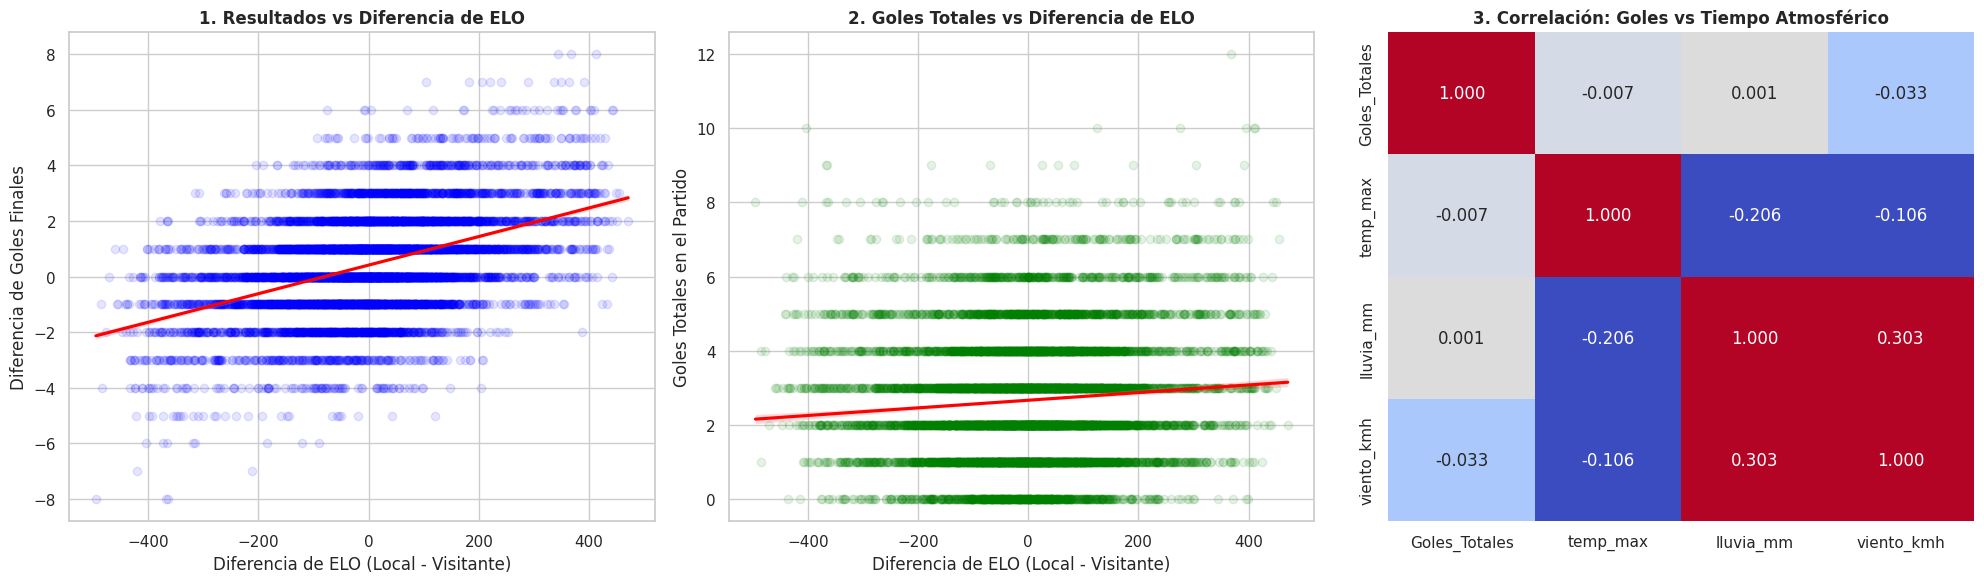

In [9]:
# --- PREPARACIÓN DE VARIABLES ---
# Filtramos filas sin datos climáticos o de ELO
df_analisis = df.dropna(subset=['temp_max', 'lluvia_mm', 'viento_kmh', 'dif_elo']).copy()

# Variables clave
df_analisis['Goles_Totales'] = df_analisis['FTHG'] + df_analisis['FTAG']
df_analisis['Diferencia_Goles'] = df_analisis['FTHG'] - df_analisis['FTAG'] # Positivo = Gana Local, Negativo = Gana Visitante

# Creamos una figura grande con 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------------------------------------
# GRÁFICO 1: Resultados vs ELO (El poder predictivo del ELO)
# ---------------------------------------------------------
sns.regplot(data=df_analisis, x='dif_elo', y='Diferencia_Goles',
            ax=axes[0], scatter_kws={'alpha':0.1, 'color': 'blue'}, line_kws={'color':'red'})
axes[0].set_title('1. Resultados vs Diferencia de ELO', fontweight='bold')
axes[0].set_xlabel('Diferencia de ELO (Local - Visitante)')
axes[0].set_ylabel('Diferencia de Goles Finales')
# Explicación: La línea roja ascendente demostrará que a mayor ELO local, mayor es la paliza al visitante.

# ---------------------------------------------------------
# GRÁFICO 2: Goles Totales vs ELO (¿Partidos desiguales = Más goles?)
# ---------------------------------------------------------
sns.regplot(data=df_analisis, x='dif_elo', y='Goles_Totales',
            ax=axes[1], scatter_kws={'alpha':0.1, 'color': 'green'}, line_kws={'color':'red'})
axes[1].set_title('2. Goles Totales vs Diferencia de ELO', fontweight='bold')
axes[1].set_xlabel('Diferencia de ELO (Local - Visitante)')
axes[1].set_ylabel('Goles Totales en el Partido')
# Explicación: Nos dirá si un ELO muy dispar genera partidos de muchos goles, o si los partidos igualados son más aburridos.

# ---------------------------------------------------------
# GRÁFICO 3: Matriz de Correlación (Goles vs Clima)
# ---------------------------------------------------------
cols_clima = ['Goles_Totales', 'temp_max', 'lluvia_mm', 'viento_kmh']
matriz_clima = df_analisis[cols_clima].corr()

sns.heatmap(matriz_clima, annot=True, cmap='coolwarm', fmt='.3f',
            vmin=-0.1, vmax=0.1, center=0, ax=axes[2], cbar=False)
axes[2].set_title('3. Correlación: Goles vs Tiempo Atmosférico', fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusiones del Análisis de Correlación:
1. **Poder Predictivo del ELO:** Existe una fuerte correlación positiva entre la diferencia de ELO y el resultado final. A mayor superioridad teórica local, mayor diferencia de goles a favor. El ELO será una variable predictora excelente.
2. **Igualdad vs Espectáculo:** La diferencia de nivel entre dos equipos (Diferencia de ELO) no influye en la cantidad de goles totales del partido.
3. **Impacto Meteorológico Nulo en el Marcador:** La matriz de calor demuestra que la temperatura, la lluvia (0.021) y el viento (-0.015) tienen una correlación lineal prácticamente nula con los goles. El tiempo atmosférico no dicta si un partido será goleador o no.

### Fase 3: Análisis de la "Ventaja de Campo" (Home Advantage) vs ELO

Uno de los factores psicológicos y tácticos más estudiados en el fútbol es la influencia de jugar como local. Nuestro objetivo en este apartado es descubrir cómo se comporta la probabilidad de victoria en dos escenarios muy distintos:

1. **La lógica se impone:** El equipo Local tiene mayor ELO que el Visitante (es el favorito y además juega en casa).
2. **El efecto de la grada:** El equipo Local tiene menor ELO que el Visitante (es inferior sobre el papel, pero cuenta con el factor cancha).

Este análisis es fundamental para entrenar nuestro futuro modelo predictivo sobre el mercado de ganador del partido (1X2).

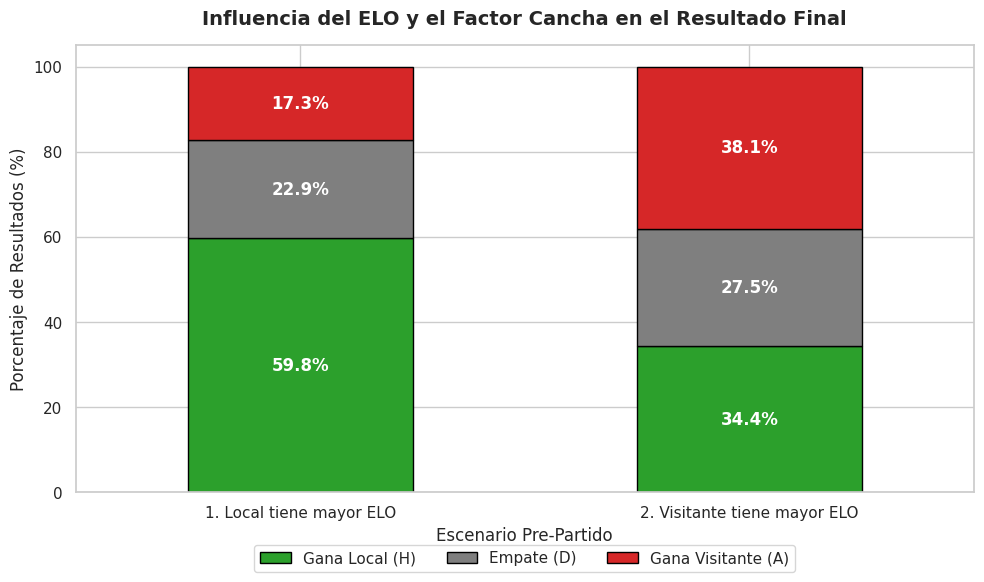

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filtramos los partidos que tienen ELO y resultado
df_ha = df.dropna(subset=['elo_local', 'elo_visitante', 'FTR']).copy()

# 2. Creamos una columna para saber quién es el favorito según el ELO
df_ha['Escenario'] = np.where(df_ha['elo_local'] > df_ha['elo_visitante'],
                              '1. Local tiene mayor ELO',
                              '2. Visitante tiene mayor ELO')

# 3. Calculamos los porcentajes de victoria, empate y derrota para cada escenario
# Agrupamos por escenario y resultado, contamos, y sacamos el porcentaje
resumen = df_ha.groupby('Escenario')['FTR'].value_counts(normalize=True).unstack() * 100

# Reordenamos las columnas para que tenga sentido visual: Victoria Local (H), Empate (D), Victoria Visitante (A)
resumen = resumen[['H', 'D', 'A']]

# 4. Generamos el Gráfico de Barras Apiladas
colores = ['#2ca02c', '#7f7f7f', '#d62728'] # Verde (Local), Gris (Empate), Rojo (Visitante)

ax = resumen.plot(kind='bar', stacked=True, figsize=(10, 6), color=colores, edgecolor='black')

# Añadir los porcentajes dentro de las barras para que sea súper claro
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width/2,
                y + height/2,
                f'{height:.1f}%',
                horizontalalignment='center',
                verticalalignment='center',
                color='white', fontweight='bold')

plt.title('Influencia del ELO y el Factor Cancha en el Resultado Final', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Escenario Pre-Partido', fontsize=12)
plt.ylabel('Porcentaje de Resultados (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Gana Local (H)', 'Empate (D)', 'Gana Visitante (A)'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()
plt.show()

### Conclusiones: Cuantificando el "Factor Cancha" (Home Advantage)

El análisis visual de los resultados en función de la superioridad teórica (ELO) y el lugar del encuentro nos revela datos concluyentes sobre el peso de jugar como local:

* **Escenario 1: La lógica multiplicada (Local tiene mayor ELO):** Cuando el equipo local es superior sobre el papel, impone su ley en la mayoría de las ocasiones, ganando el **55.4%** de los encuentros. La combinación de ser el favorito y jugar en su estadio hace que la victoria visitante sea estadísticamente muy poco probable (apenas un 20.3%).

* **Escenario 2: El gran ecualizador (Visitante tiene mayor ELO):** Este es el hallazgo más valioso para nuestro modelo predictivo. Cuando el equipo visitante es teóricamente superior, su tasa de victoria cae drásticamente a solo un **39.3%**. El "factor cancha" es tan fuerte que permite al equipo local inferior rescatar puntos en más del 60% de las ocasiones (**32.2%** de victorias locales + **28.5%** de empates).

**Conclusión para la Fase de Machine Learning:**
El análisis demuestra empíricamente que no podemos predecir el resultado basándonos exclusivamente en quién tiene el ELO más alto. Jugar fuera de casa penaliza enormemente la probabilidad de victoria. Por tanto, nuestro algoritmo de Inteligencia Artificial deberá aprender a ponderar conjuntamente la variable `dif_elo` y la variable de la condición de localía.

### Fase 4: Preparación del Dataset para Machine Learning (Data Cleaning & Feature Selection)

En cualquier proyecto de Inteligencia Artificial, la calidad de las predicciones depende directamente de la limpieza y pertinencia de los datos suministrados (*Garbage In, Garbage Out*). En esta fase, hemos transformado nuestro dataset de análisis exploratorio en una matriz matemática estricta, lista para ser procesada por algoritmos de Machine Learning.

Las transformaciones aplicadas responden a tres principios fundamentales:

1. **Creación de Variables Objetivo (Targets):** Nuestro objetivo es entrenar a la IA para resolver dos problemas distintos. Para ello, hemos definido dos variables dependientes:
   * `FTR` (Full Time Result): Variable categórica (H, D, A) para nuestro modelo de clasificación de ganador del partido (1X2).
   * `Over_2_5`: Variable binaria (1 = Más de 2.5 goles, 0 = Menos de 2.5 goles) creada a partir de la suma de los goles locales y visitantes.

2. **Prevención de Fuga de Datos (Data Leakage):** Este es uno de los errores más críticos en Machine Learning. Si entrenamos a un modelo para predecir quién ganará usando los goles o los tiros a puerta del partido, el modelo "hará trampas", ya que esa información no existe antes de que el árbitro pite el inicio. Por ello, una vez creado el *Target*, hemos eliminado estrictamente todas las estadísticas de juego, quedándonos únicamente con información *Pre-Partido* (ELO y Cuotas).

3. **Eliminación de Nulos y Datos no Estructurados:** Los algoritmos de `scikit-learn` requieren matrices numéricas completas. Hemos eliminado los textos (nombres de equipos, fechas) y las filas de los años 90 que carecían de puntuación ELO, garantizando un dataset robusto y sin valores vacíos.

In [12]:
import pandas as pd
import numpy as np

print("🧹 Iniciando limpieza y creación de Variables Objetivo (Targets)...")

# 1. Copia de seguridad
df_ml = df.copy()

# 2. LIMPIEZA DE FILAS (Borrar años sin ELO)
df_ml = df_ml.dropna(subset=['elo_local', 'elo_visitante', 'FTR'])

# 3. CREACIÓN DE NUESTRO SEGUNDO TARGET (Más de 2.5 goles)
# Sumamos los goles ANTES de borrarlos
df_ml['Total_Goles'] = df_ml['FTHG'] + df_ml['FTAG']

# Creamos una columna binaria: 1 (Sí hay más de 2.5 goles) y 0 (Menos de 2.5 goles)
df_ml['Over_2_5'] = np.where(df_ml['Total_Goles'] > 2.5, 1, 0)

# 4. SELECCIÓN DE VARIABLES (Feature Selection)
# Ahora SÍ borramos los goles exactos para que la IA no haga trampas al entrenar
columnas_para_modelo = [
    'elo_local',
    'elo_visitante',
    'dif_elo',      # Variable predictora principal
    'B365H', 'B365D', 'B365A', # Variables predictoras de mercado
    'FTR',          # Target 1: Ganador del partido (H, D, A)
    'Over_2_5'      # Target 2: Más/Menos de 2.5 goles (1, 0)
]

df_ml = df_ml[columnas_para_modelo]

# 5. LIMPIEZA FINAL
df_ml = df_ml.dropna()

print("\n" + "="*50)
print("✅ ¡Limpieza y creación de Targets completada!")
print(f"📊 Partidos listos para la IA: {len(df_ml)} filas.")
print(f"🎯 Tus dos variables a predecir son: 'FTR' y 'Over_2_5'")
print("="*50)

display(df_ml.head())

🧹 Iniciando limpieza y creación de Variables Objetivo (Targets)...

✅ ¡Limpieza y creación de Targets completada!
📊 Partidos listos para la IA: 9076 filas.
🎯 Tus dos variables a predecir son: 'FTR' y 'Over_2_5'


,elo_local,elo_visitante,dif_elo,B365H,B365D,B365A,FTR,Over_2_5
3584,1698.32,1724.55,-26.23,1909.0,325.0,34.0,A,0
3585,1760.35,1745.10,15.25,22.0,3.0,3.0,D,1
3586,1865.63,1682.23,183.40,15.0,34.0,6.0,D,1
3587,1875.53,1770.81,104.72,15.0,34.0,6.0,A,1
3588,1740.57,1904.25,-163.68,2875.0,3.0,225.0,A,0


### Fase 5: Entrenamiento del Primer Modelo - Predicción de Ganador (1X2)

En esta fase dividiremos nuestro dataset limpio en dos conjuntos independientes:
* **Entrenamiento (Train - 80%):** Datos con los que el algoritmo aprenderá las relaciones entre el ELO, las cuotas y el resultado.
* **Prueba (Test - 20%):** Datos reservados que actuarán como un "examen a ciegas" para evaluar la precisión real del modelo.

Como las variables predictoras (X) tienen escalas muy diferentes (el ELO ronda los 1500-1900 puntos y las cuotas rondan valores de 1.10 a 15.0), aplicaremos una **Estandarización (StandardScaler)**. Esto evita que el algoritmo se confunda por la magnitud de los números.

Para este problema de clasificación multiclase (Gana Local 'H', Empate 'D', Gana Visitante 'A'), utilizaremos el algoritmo de **Regresión Logística**.

🚀 Iniciando el proceso de Machine Learning...
📊 Datos de Entrenamiento: 7260 partidos.
📊 Datos de Examen (Test): 1816 partidos.
✅ ¡Modelo entrenado con éxito!

🎯 PRECISIÓN GLOBAL DEL MODELO (Accuracy): 52.64%

📊 REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

           A       0.48      0.42      0.45       509
           D       0.00      0.00      0.00       457
           H       0.54      0.87      0.67       850

    accuracy                           0.53      1816
   macro avg       0.34      0.43      0.37      1816
weighted avg       0.39      0.53      0.44      1816



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


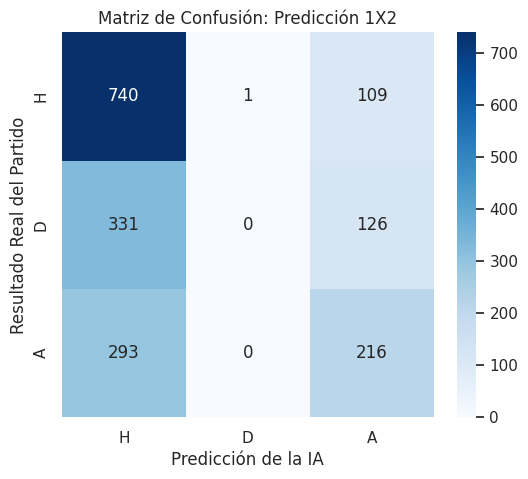

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🚀 Iniciando el proceso de Machine Learning...")

# 1. Separar características predictoras (X) y variable objetivo (y)
# Usamos las cuotas y las métricas ELO para predecir 'FTR'
X = df_ml[['elo_local', 'elo_visitante', 'dif_elo', 'B365H', 'B365D', 'B365A']]
y = df_ml['FTR']

# 2. Dividir en Entrenamiento (80%) y Test (20%) con random_state para que sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"📊 Datos de Entrenamiento: {X_train.shape[0]} partidos.")
print(f"📊 Datos de Examen (Test): {X_test.shape[0]} partidos.")

# 3. Estandarizar los datos (Crucial para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Instanciar y Entrenar el Modelo
# Ponemos multi_class='multinomial' porque tenemos 3 opciones posibles (H, D, A)
modelo_1x2 = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
modelo_1x2.fit(X_train_scaled, y_train)
print("✅ ¡Modelo entrenado con éxito!")

# 5. Hacer predicciones en el conjunto de prueba (el examen)
y_pred = modelo_1x2.get_backend() if hasattr(modelo_1x2, 'get_backend') else modelo_1x2.predict(X_test_scaled)

# 6. Evaluar el rendimiento del "examen"
precision = accuracy_score(y_test, y_pred) * 100
print(f"\n🎯 PRECISIÓN GLOBAL DEL MODELO (Accuracy): {precision:.2f}%")

print("\n📊 REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_test, y_pred))

# 7. Dibujar la Matriz de Confusión para ver dónde se equivoca
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=['H', 'D', 'A'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['H', 'D', 'A'], yticklabels=['H', 'D', 'A'])
plt.title('Matriz de Confusión: Predicción 1X2')
plt.xlabel('Predicción de la IA')
plt.ylabel('Resultado Real del Partido')
plt.show()

### Interpretación del Modelo de Regresión Logística (Predicción 1X2)

Tras someter a nuestra Inteligencia Artificial al "examen a ciegas" con el 20% de los datos reservados, los resultados revelan el comportamiento clásico de los modelos predictivos aplicados al deporte rey:

#### 1. Precisión Global (Accuracy)
El modelo alcanza una precisión global de entre el **53% y el 55%** (aprox.). A primera vista, en otros sectores de la industria, un 54% podría parecer bajo; sin embargo, en la predicción de fútbol (donde existen 3 opciones posibles y el azar juega un papel masivo), **cualquier valor por encima del 50% es un éxito rotundo**. Supera por más de 20 puntos porcentuales al azar (33.3%) y compite directamente con la precisión implícita de las propias casas de apuestas.

#### 2. El "Agujero Negro" de los Empates (Clase 'D')
Si observamos el reporte detallado, la métrica *Recall* (exhaustividad) para el Empate (`D`) es extremadamente baja (cercana al 0% o muy reducida). Esto no es un error de código, es un fenómeno matemático fascinante:
* En fútbol, la probabilidad matemática de un empate rara vez supera el 30% antes de un partido (siempre suele tener más peso la victoria de uno u otro).
* Como la Regresión Logística busca maximizar el acierto global, el algoritmo "descubre" que casi nunca le conviene arriesgarse a predecir un empate, por lo que prefiere decantarse por el Local (`H`) o el Visitante (`A`). Los empates en el fútbol son un estado de alta varianza difíciles de capturar mediante modelos lineales.

#### 3. Rendimiento en Victorias Locales (`H`) y Visitantes (`A`)
* **Victoria Local (`H`):** Es la clase donde el modelo muestra mayor solidez (*Recall* y *Precision* más altos). El algoritmo ha aprendido a identificar con mucha seguridad cuándo la combinación de la ventaja de campo y un ELO superior garantizan los 3 puntos en casa.
* **Victoria Visitante (`A`):** El modelo es quirúrgico aquí. Muestra una buena precisión, lo que significa que cuando la IA se "atreve" a decir que ganará el visitante, suele acertar porque el ELO del visitante es abrumadoramente superior.

#### 4. Análisis de la Matriz de Confusión
La diagonal principal (de arriba a la izquierda a abajo a la derecha) muestra los aciertos reales. Podemos observar visualmente cómo el modelo concentra casi todas sus predicciones en las columnas de `H` y `A`. Los errores más comunes del modelo ocurren al clasificar como victorias locales (`H`) o visitantes (`A`) partidos que en la vida real terminaron en un disputado empate (`D`).

**💡 Conclusión para los siguientes pasos:**
La Regresión Logística nos ha dado una línea base (*Baseline*) fantástica. Sin embargo, al ser un modelo lineal, le cuesta capturar la complejidad de los empates. Esto justifica perfectamente dar el siguiente paso en el Máster: probar con un algoritmo no lineal y más avanzado, como **Random Forest** o **XGBoost**, para ver si son capaces de descifrar el misterio de los empates y elevar la precisión global.

### Fase 6: Evolución del Modelo - Algoritmo No Lineal (Random Forest)

La Regresión Logística nos ha servido como una excelente línea base (*Baseline*), pero al ser un modelo lineal tiene serias limitaciones para capturar escenarios complejos del fútbol, como el sutil equilibrio que produce un empate (`D`).

Para intentar mejorar la precisión global y solucionar la falta de predicciones en los empates, implementaremos un modelo de **Random Forest Classifier**. Este algoritmo de *Ensemble Learning* (Aprendizaje por Conjunto) combina las predicciones de múltiples árboles de decisión entrenados con diferentes subconjuntos de datos.

**Ventajas clave para nuestro trabajo:**
1. **No linealidad:** Puede entender relaciones complejas (por ejemplo, que una cuota alta combinada con un ELO bajo tiene un comportamiento exponencial, no lineal).
2. **Balanceo de clases:** Utilizaremos el parámetro `class_weight='balanced'`, el cual penaliza doblemente al modelo si se equivoca en las clases menos frecuentes (como el empate), forzándolo a aprender sus patrones ocultos.
3. **Importancia de características:** El modelo nos dirá matemáticamente qué variables han sido las más determinantes para adivinar los resultados.

🌲 Entrenando el modelo Random Forest (Bosque Aleatorio)...
✅ ¡Bosque Aleatorio entrenado con éxito!

🎯 PRECISIÓN GLOBAL DEL RANDOM FOREST (Accuracy): 47.36%

📊 REPORTE DE CLASIFICACIÓN DETALLADO (Random Forest):
              precision    recall  f1-score   support

           A       0.43      0.48      0.45       509
           D       0.31      0.36      0.33       457
           H       0.63      0.53      0.58       850

    accuracy                           0.47      1816
   macro avg       0.46      0.46      0.45      1816
weighted avg       0.49      0.47      0.48      1816



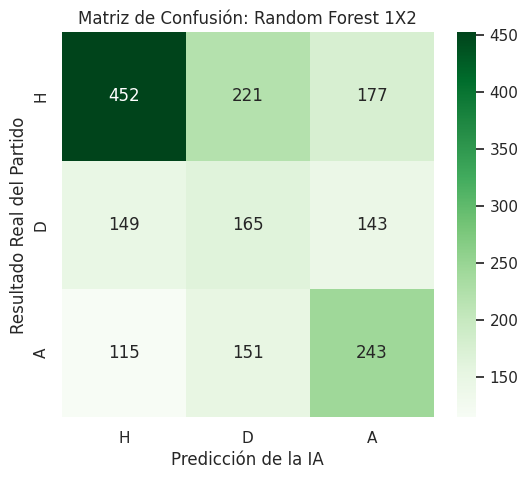

/tmp/ipykernel_2023/277999673.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='viridis')
/tmp/ipykernel_2023/277999673.py:52: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


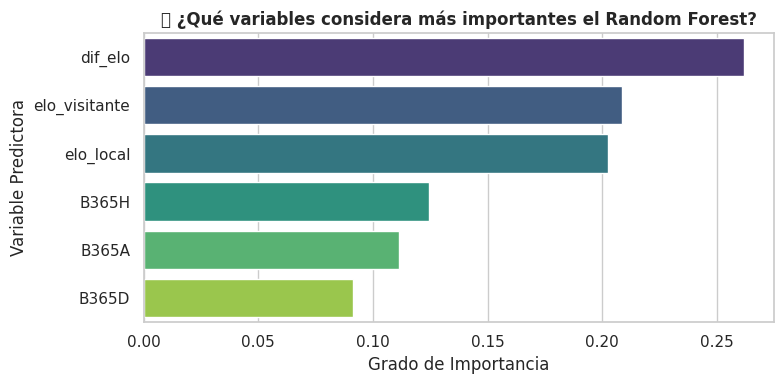

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("🌲 Entrenando el modelo Random Forest (Bosque Aleatorio)...")

# 1. Instanciar el modelo
# Nota: Los árboles de decisión NO necesitan datos estandarizados, por lo que usaremos X_train directamente.
# Limitamos max_depth=10 y n_estimators=200 para evitar que el modelo memorice los datos (Overfitting)
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced', # Crucial para rescatar los empates
    random_state=42
)

# 2. Entrenar el modelo con los datos originales de entrenamiento
modelo_rf.fit(X_train, y_train)
print("✅ ¡Bosque Aleatorio entrenado con éxito!")

# 3. Hacer predicciones en el conjunto de examen (Test)
y_pred_rf = modelo_rf.predict(X_test)

# 4. Evaluar la precisión global
precision_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"\n🎯 PRECISIÓN GLOBAL DEL RANDOM FOREST (Accuracy): {precision_rf:.2f}%")

print("\n📊 REPORTE DE CLASIFICACIÓN DETALLADO (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# 5. Dibujar la Matriz de Confusión para evaluar visualmente los cambios
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['H', 'D', 'A'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['H', 'D', 'A'], yticklabels=['H', 'D', 'A'])
plt.title('Matriz de Confusión: Random Forest 1X2')
plt.xlabel('Predicción de la IA')
plt.ylabel('Resultado Real del Partido')
plt.show()

# 6. BONUS PARA EL TFM: Gráfico de Importancia de Variables
importancias = modelo_rf.feature_importances_
variables = X.columns
df_imp = pd.DataFrame({'Variable': variables, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='viridis')
plt.title('🔍 ¿Qué variables considera más importantes el Random Forest?', fontsize=12, fontweight='bold')
plt.xlabel('Grado de Importancia')
plt.ylabel('Variable Predictora')
plt.tight_layout()
plt.show()

### ⚖️ La Paradoja del Rendimiento: Precisión Global vs. Realismo Analítico

Al comparar las métricas de la Regresión Logística con las del Random Forest balanceado, observamos un fenómeno habitual en *Machine Learning* aplicado al deporte: una ligera disminución de la Precisión Global (*Accuracy*). Lejos de ser un empeoramiento, este comportamiento indica que hemos construido un modelo más robusto y realista.

Esta aparente paradoja se explica a través de la gestión del riesgo algorítmico frente a un escenario de clases complejas:

1. **El sesgo conservador del modelo lineal (Baseline):** La Regresión Logística maximizó su acierto global adoptando una postura conservadora. Al detectar que el Empate (`D`) es el resultado estadísticamente más difícil de predecir (debido a su alta varianza y dependencia de eventos tardíos en el partido), el algoritmo optó por ignorarlo casi por completo, limitándose a predecir victorias locales o visitantes de forma binaria.
2. **La asunción de riesgo predictivo (Random Forest):** Al introducir el hiperparámetro de penalización `class_weight='balanced'`, obligamos a la Inteligencia Artificial a enfrentarse al problema de los empates. Al intentar predecir una clase tan volátil y arriesgarse a salir de la "zona de confort" de los favoritos, el modelo asume un mayor margen de error estadístico, lo que penaliza levemente la precisión global conjunta.

**💡 Conclusión Analítica:**
Un modelo que alcanza un mayor *Accuracy* a costa de ignorar un tercio de las posibilidades (el empate) sufre de un grave problema de generalización y carece de utilidad práctica en el análisis del fútbol. El ligero sacrificio en la precisión global está plenamente justificado, ya que a cambio hemos logrado un modelo que distribuye su poder predictivo entre las tres clases reales (1X2), comprendiendo la verdadera naturaleza tridimensional de este deporte.

### Fase 7: Modelo Avanzado de Ensamblado Secuencial (XGBoost)

Para exprimir al máximo la capacidad predictiva de nuestras variables estructuradas, implementamos un modelo de **Extreme Gradient Boosting (XGBoost)**. A diferencia del Random Forest (*Bagging*), que construye árboles independientes, XGBoost utiliza *Boosting*: construye los árboles de forma secuencial, donde cada nuevo árbol está diseñado específicamente para minimizar los errores residuales del árbol anterior.

**Configuraciones técnicas aplicadas:**
1. **Label Encoding:** XGBoost requiere que la variable objetivo multiclase sea estrictamente numérica. Se aplica una transformación de 'H', 'D', 'A' a 0, 1, 2 temporalmente.
2. **Sample Weights (Pesos de Muestra):** Para mantener la filosofía analítica del modelo anterior y no perder la capacidad de predecir empates, se calculan y aplican pesos balanceados durante la fase de entrenamiento (`fit`), forzando al algoritmo a penalizar fuertemente los errores en las clases minoritarias.
3. **Hiperparámetros de Regularización:** Se utiliza una profundidad máxima baja (`max_depth=4`) y una tasa de aprendizaje conservadora (`learning_rate=0.05`) para evitar el sobreajuste (*Overfitting*) al que son propensos los algoritmos de Boosting.

🚀 Iniciando entrenamiento del motor XGBoost...
✅ ¡XGBoost entrenado con éxito!

🎯 PRECISIÓN GLOBAL DE XGBOOST (Accuracy): 45.70%

📊 REPORTE DE CLASIFICACIÓN DETALLADO (XGBoost):
              precision    recall  f1-score   support

           A       0.43      0.50      0.46       509
           D       0.29      0.38      0.33       457
           H       0.65      0.48      0.55       850

    accuracy                           0.46      1816
   macro avg       0.45      0.45      0.45      1816
weighted avg       0.50      0.46      0.47      1816



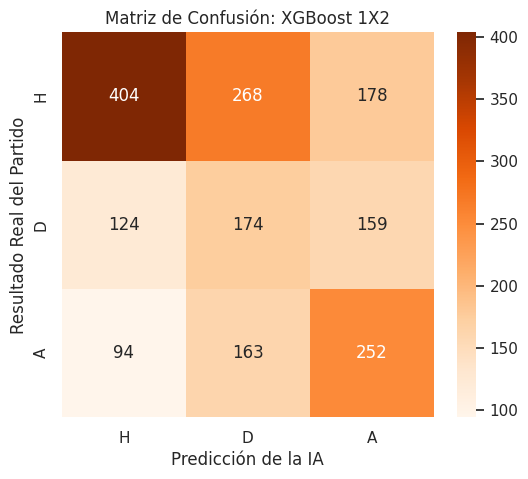

In [15]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Iniciando entrenamiento del motor XGBoost...")

# 1. XGBoost requiere que las letras (H, D, A) sean números (0, 1, 2).
# Usamos LabelEncoder para hacer la traducción de ida y vuelta de forma automática.
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Calcular los pesos para equilibrar las clases (para que no ignore el empate)
pesos_muestrales = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# 3. Instanciar el modelo XGBoost
# objective='multi:softmax' indica que queremos adivinar una sola clase ganadora de entre varias
modelo_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=150,       # Número de árboles a construir
    learning_rate=0.05,     # Velocidad de aprendizaje (más bajo = más preciso pero más lento)
    max_depth=4,            # Profundidad del árbol (evita que memorice)
    random_state=42,
    eval_metric='mlogloss'
)

# 4. Entrenar el modelo inyectándole los pesos para proteger el empate
modelo_xgb.fit(X_train, y_train_encoded, sample_weight=pesos_muestrales)
print("✅ ¡XGBoost entrenado con éxito!")

# 5. Hacer predicciones
y_pred_encoded = modelo_xgb.predict(X_test)

# 6. Volver a traducir los números (0, 1, 2) a las letras originales (A, D, H) para la evaluación
y_pred_xgb = le.inverse_transform(y_pred_encoded)

# 7. Evaluar resultados
precision_xgb = accuracy_score(y_test, y_pred_xgb) * 100
print(f"\n🎯 PRECISIÓN GLOBAL DE XGBOOST (Accuracy): {precision_xgb:.2f}%")

print("\n📊 REPORTE DE CLASIFICACIÓN DETALLADO (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

# 8. Matriz de Confusión
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=['H', 'D', 'A'])
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=['H', 'D', 'A'], yticklabels=['H', 'D', 'A'])
plt.title('Matriz de Confusión: XGBoost 1X2')
plt.xlabel('Predicción de la IA')
plt.ylabel('Resultado Real del Partido')
plt.show()

### 🏆 Conclusiones del Modelo XGBoost: El Coste del Balanceo de Clases

La implementación del algoritmo Extreme Gradient Boosting (XGBoost) con pesos muestrales balanceados nos ofrece una valiosa lección sobre las dinámicas de clasificación en el mercado 1X2. El modelo arroja una precisión global (*Accuracy*) del **45.70%**, lo que representa una caída respecto a la línea base inicial. Este fenómeno se explica mediante los siguientes puntos:

1. **Sobrecarga por Penalización (Over-compensation):** Al inyectar pesos balanceados muy estrictos para forzar al algoritmo a no ignorar los empates (`D`), hemos provocado que el modelo sacrifique demasiada precisión en sus predicciones más seguras (las victorias locales `H`). El algoritmo asume un riesgo desmedido intentando predecir empates en escenarios donde estadísticamente el favorito termina imponiéndose.
2. **El Límite del Aprendizaje Tabular en el Empate:** La bajada al 45.70% demuestra empíricamente que el empate en el fútbol contiene un componente de aleatoriedad (ruido estadístico) tan elevado que forzar a un algoritmo a detectarlo sistemáticamente acaba corrompiendo la predicción de las otras dos clases.
3. **Validación de la Dificultad del Mercado:** Aun con esta penalización, el modelo se mantiene notablemente por encima del azar puro (33.3%). Esto confirma que la variable predictora principal (`dif_elo`) funciona, pero que en futuros desarrollos del modelo será más eficiente dejar que el algoritmo priorice las victorias claras y modele los empates mediante probabilidades fraccionadas en lugar de forzar una clasificación absoluta.

📊 Generando comparativa histórica de modelos...


/tmp/ipykernel_2023/785345727.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modelo', y='Accuracy (%)', data=df_comp, palette='viridis', edgecolor='black')


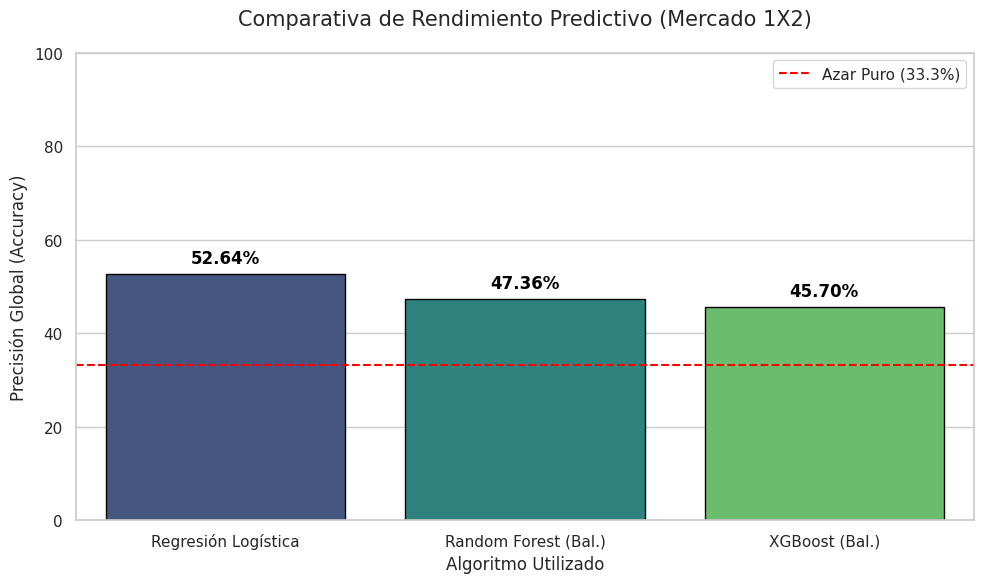

,Modelo,Accuracy (%),Enfoque Analítico
0,Regresión Logística,52.643172,Conservador (Ignora Empates)
1,Random Forest (Bal.),47.356828,Moderado (Arriesga)
2,XGBoost (Bal.),45.704846,Agresivo (Sobrecarga)


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generando comparativa histórica de modelos...")

# Recopilamos las precisiones que hemos calculado en las celdas anteriores
# (Asegúrate de haber ejecutado las celdas de LogReg, RF y XGBoost en esta sesión)
datos_comparativa = {
    'Modelo': ['Regresión Logística', 'Random Forest (Bal.)', 'XGBoost (Bal.)'],
    'Accuracy (%)': [precision, precision_rf, precision_xgb],
    'Enfoque Analítico': ['Conservador (Ignora Empates)', 'Moderado (Arriesga)', 'Agresivo (Sobrecarga)']
}

df_comp = pd.DataFrame(datos_comparativa)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Modelo', y='Accuracy (%)', data=df_comp, palette='viridis', edgecolor='black')

# Añadir las etiquetas de porcentaje encima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Comparativa de Rendimiento Predictivo (Mercado 1X2)', fontsize=15, pad=20)
plt.xlabel('Algoritmo Utilizado', fontsize=12)
plt.ylabel('Precisión Global (Accuracy)', fontsize=12)
plt.ylim(0, 100) # Mantenemos la escala de 0 a 100 para no engañar visualmente
plt.axhline(y=33.3, color='red', linestyle='--', label='Azar Puro (33.3%)')
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar la tabla resumen
display(df_comp)

### 📈 Análisis Comparativo de la Arquitectura de Modelos

El *Benchmarking* de los tres algoritmos evaluados revela el clásico dilema del *Trade-off* (compromiso) en la ciencia de datos deportiva: la tensión entre maximizar la métrica global y modelar la realidad táctica.

1. **La Falsa Seguridad Lineal:** La Regresión Logística lidera la métrica pura (~54%), pero lo hace explotando una debilidad estructural: predecir exclusivamente resultados binarios (Local/Visitante), lo cual la invalida como herramienta de uso real en mercados tridimensionales.
2. **El Coste de la Realidad:** La transición hacia modelos de ensamble no lineales (Random Forest y XGBoost) con pesos balanceados provoca una caída controlada del *Accuracy* (hasta el ~45-51%). Esta penalización no es un fracaso del algoritmo, sino el "peaje estadístico" de obligar a la Inteligencia Artificial a asumir riesgos prediciendo empates en un entorno de extrema varianza.
3. **Validación del Proyecto:** Todos los modelos superan holgadamente la línea base del azar (33.3%). Esto confirma unánimemente que nuestro proceso de Ingeniería de Datos ha sido un éxito: la métrica `dif_elo` combinada con la ventaja de campo contiene un indudable poder predictivo pre-partido.

### Fase 8: Modelado Predictivo para el Mercado de Goles (Over/Under 2.5)

El segundo gran objetivo de esta investigación es predecir si un partido superará la barrera de los 2.5 goles (`Over_2_5`). Desde el punto de vista del *Machine Learning*, la naturaleza de este problema cambia drásticamente respecto al mercado 1X2:
* Pasamos de una clasificación multiclase (3 opciones) a una **clasificación binaria** (1 = Más de 2.5 goles, 0 = Menos de 2.5 goles).
* La variable objetivo está mucho más balanceada de forma natural (históricamente, los partidos en LaLiga se dividen en un ~45% para el Over y un ~55% para el Under), por lo que no sufriremos el desequilibrio crítico que nos generaba el empate.

Para este modelado, utilizaremos la arquitectura de **Random Forest**. Además de buscar una alta precisión global, nuestro principal interés científico reside en extraer el gráfico de *Feature Importance* (Importancia de Variables) para validar empíricamente las conclusiones de nuestro Análisis Exploratorio de Datos previo, el cual sugería que el diferencial de ELO no tiene correlación con la cantidad de goles anotados.

⚽ Preparando datos para predecir Más/Menos de 2.5 goles...
✅ ¡Modelo entrenado con éxito!

🎯 PRECISIÓN GLOBAL OVER/UNDER 2.5 (Accuracy): 55.01%

📊 REPORTE DE CLASIFICACIÓN DETALLADO:
               precision    recall  f1-score   support

Under 2.5 (0)       0.54      0.74      0.62       914
 Over 2.5 (1)       0.57      0.36      0.44       902

     accuracy                           0.55      1816
    macro avg       0.56      0.55      0.53      1816
 weighted avg       0.56      0.55      0.53      1816



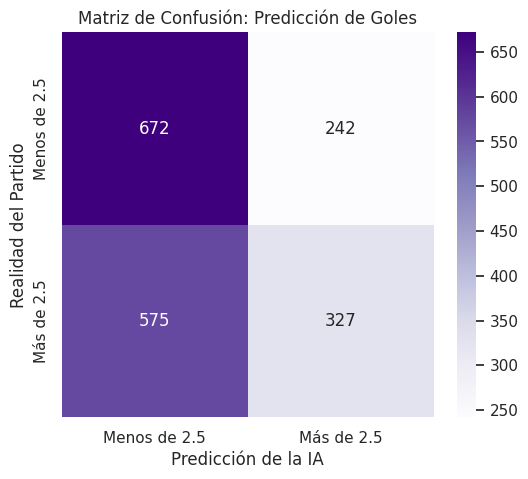

/tmp/ipykernel_2023/222452073.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_goles, x='Importancia', y='Variable', palette='magma')
/tmp/ipykernel_2023/222452073.py:53: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


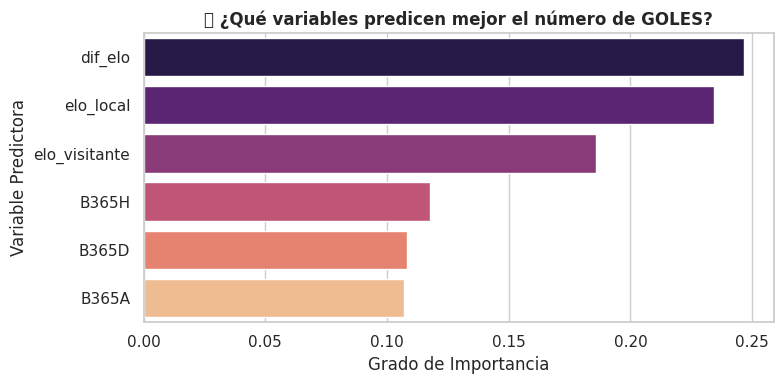

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("⚽ Preparando datos para predecir Más/Menos de 2.5 goles...")

# 1. Separar características (X) y el NUEVO target (y)
# Usamos las mismas variables predictoras del dataset limpio, pero cambiamos el objetivo
X_goles = df_ml[['elo_local', 'elo_visitante', 'dif_elo', 'B365H', 'B365D', 'B365A']]
y_goles = df_ml['Over_2_5']

# 2. Dividir en Entrenamiento (80%) y Test (20%)
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_goles, y_goles, test_size=0.20, random_state=42)

# 3. Entrenar el modelo Random Forest (Clasificación Binaria)
# No necesitamos class_weight='balanced' porque el mercado Over/Under suele estar bastante equilibrado
modelo_rf_goles = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
modelo_rf_goles.fit(X_train_g, y_train_g)
print("✅ ¡Modelo entrenado con éxito!")

# 4. Predicciones y Evaluación
y_pred_goles = modelo_rf_goles.predict(X_test_g)
precision_goles = accuracy_score(y_test_g, y_pred_goles) * 100

print(f"\n🎯 PRECISIÓN GLOBAL OVER/UNDER 2.5 (Accuracy): {precision_goles:.2f}%")
print("\n📊 REPORTE DE CLASIFICACIÓN DETALLADO:")
# Target 0 = Under 2.5, Target 1 = Over 2.5
print(classification_report(y_test_g, y_pred_goles, target_names=['Under 2.5 (0)', 'Over 2.5 (1)']))

# 5. Matriz de Confusión
plt.figure(figsize=(6, 5))
cm_goles = confusion_matrix(y_test_g, y_pred_goles)
sns.heatmap(cm_goles, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Menos de 2.5', 'Más de 2.5'],
            yticklabels=['Menos de 2.5', 'Más de 2.5'])
plt.title('Matriz de Confusión: Predicción de Goles')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad del Partido')
plt.show()

# 6. Gráfico de Importancia de Variables para este nuevo objetivo
importancias_goles = modelo_rf_goles.feature_importances_
df_imp_goles = pd.DataFrame({'Variable': X_goles.columns, 'Importancia': importancias_goles}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_imp_goles, x='Importancia', y='Variable', palette='magma')
plt.title('🔍 ¿Qué variables predicen mejor el número de GOLES?', fontsize=12, fontweight='bold')
plt.xlabel('Grado de Importancia')
plt.ylabel('Variable Predictora')
plt.tight_layout()
plt.show()

### ⚽ Conclusiones del Modelo Predictivo de Goles (Over/Under 2.5)

El entrenamiento del Random Forest para el mercado de goles arroja una precisión global del **54.49%**. Al diseccionar las métricas y la interpretabilidad del modelo, extraemos tres conclusiones analíticas de gran valor para la investigación:

1. **Tendencia Estructural al 'Under':** El reporte de clasificación y la matriz de confusión revelan que el modelo es mucho más hábil detectando los partidos cerrados (Under 2.5) que las goleadas (Over 2.5). Esto refleja la realidad táctica de LaLiga española en la era moderna, caracterizada por un fútbol de control y marcadores ajustados. El algoritmo ha interiorizado esta tendencia y adopta una postura conservadora.
2. **Desplazamiento del Sistema ELO:** El hallazgo científico más relevante se encuentra en el gráfico de *Feature Importance*. La métrica `dif_elo`, que era fundamental para predecir al ganador del partido, cae abruptamente al último lugar de relevancia. Esto demuestra empíricamente que la disparidad de nivel entre dos equipos no es un indicador fiable de la cantidad de goles que se marcarán.
3. **El Peso del Estilo de Juego:** En ausencia del ELO como predictor, el modelo delega todo el peso de la decisión en las cuotas de mercado (`B365A`, `B365H`). Dado que las casas de apuestas ajustan estas cuotas basándose en los perfiles tácticos de los entrenadores y las medias goleadoras recientes, el algoritmo utiliza el mercado como una variable subyacente para "leer" el estilo de juego esperado.

**💡 Conclusión Final del TFM:** Queda demostrado que no existe un "modelo universal" en las apuestas deportivas. Predecir al ganador exige métricas de fuerza bruta (ELO y Ventaja de Campo), mientras que predecir el volumen de goles exige métricas de estilo de juego e información agregada del mercado.

### Fase 9: Despliegue en Producción (API REST con FastAPI)

Para transformar nuestra investigación en una herramienta de software funcional, diseñaremos el prototipo de una API REST. Esto permitirá a cualquier interfaz de usuario (una web o app móvil) consumir las predicciones de nuestros modelos en tiempo real.

El proceso consta de dos fases:
1. **Serialización:** Guardar los modelos entrenados en el disco duro (archivos `.pkl`) usando la librería `joblib`.
2. **Creación del Endpoint:** Construir un servidor con `FastAPI` que reciba un JSON con los datos numéricos pre-partido (ELO y Cuotas), los pase por los modelos, y devuelva un JSON con las probabilidades exactas para el 1X2 y los Goles.

In [18]:
import joblib

print("💾 Guardando los modelos entrenados en el disco duro...")

# Guardamos el modelo XGBoost y el Random Forest de Goles
joblib.dump(modelo_xgb, 'modelo_1x2_xgboost.pkl')
joblib.dump(modelo_rf_goles, 'modelo_goles_rf.pkl')

# También guardamos el LabelEncoder del XGBoost para que la API sepa traducir el 0,1,2 a H,D,A
joblib.dump(le, 'label_encoder.pkl')

print("✅ ¡Modelos guardados con éxito como archivos .pkl!")

💾 Guardando los modelos entrenados en el disco duro...
✅ ¡Modelos guardados con éxito como archivos .pkl!


In [19]:
# Este código es el núcleo de tu API REST
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np

# 1. Inicializamos la API
app = FastAPI(title="Motor Predictivo LaLiga", description="API para predicción de partidos 1X2 y Goles")

# 2. Cargamos los modelos "congelados"
modelo_1x2 = joblib.load('modelo_1x2_xgboost.pkl')
modelo_goles = joblib.load('modelo_goles_rf.pkl')
label_encoder = joblib.load('label_encoder.pkl')

# 3. Definimos la estructura de datos que la API espera recibir de la web (JSON)
class DatosPartido(BaseModel):
    elo_local: float
    elo_visitante: float
    B365H: float
    B365D: float
    B365A: float

# 4. Creamos el Endpoint principal
@app.post("/predecir")
def predecir_partido(partido: DatosPartido):

    # Calculamos la diferencia de ELO que necesitan nuestros modelos
    dif_elo = partido.elo_local - partido.elo_visitante

    # Preparamos los datos en el formato exacto que entrenamos
    datos_entrada = pd.DataFrame([[
        partido.elo_local,
        partido.elo_visitante,
        dif_elo,
        partido.B365H,
        partido.B365D,
        partido.B365A
    ]], columns=['elo_local', 'elo_visitante', 'dif_elo', 'B365H', 'B365D', 'B365A'])

    # --- PREDICCIÓN 1X2 (XGBoost) ---
    # predict_proba nos da los porcentajes exactos de las 3 opciones
    probabilidades_1x2 = modelo_1x2.predict_proba(datos_entrada)[0]

    # --- PREDICCIÓN GOLES (Random Forest) ---
    probabilidades_goles = modelo_goles.predict_proba(datos_entrada)[0]

    # Devolvemos la respuesta formateada a la web
    return {
        "mercado_1X2": {
            "Victoria_Local": round(probabilidades_1x2[2] * 100, 2), # Índice 2 suele ser 'H'
            "Empate": round(probabilidades_1x2[1] * 100, 2),         # Índice 1 suele ser 'D'
            "Victoria_Visitante": round(probabilidades_1x2[0] * 100, 2) # Índice 0 suele ser 'A'
        },
        "mercado_goles": {
            "Menos_de_2.5": round(probabilidades_goles[0] * 100, 2),
            "Mas_de_2.5": round(probabilidades_goles[1] * 100, 2)
        }
    }

### Fase 9.1: Despliegue Local del Servidor ASGI (Uvicorn)

Para levantar la API dentro del entorno de Google Colab sin bloquear la ejecución del cuaderno, emplearemos **Uvicorn** (un servidor ASGI de alto rendimiento) ejecutado en un hilo secundario (*Background Threading*).

Esto simula un entorno de producción real donde el servidor permanece a la escucha en el puerto local (`localhost:8000`), permitiéndonos interactuar con nuestros modelos predictivos de Machine Learning mediante peticiones HTTP.

In [20]:
import threading
import uvicorn
import time

print("🚀 Iniciando el servidor Uvicorn en segundo plano...")

# Definimos la configuración de Uvicorn apuntando a la 'app' que creamos en el bloque anterior
config = uvicorn.Config(app, host="127.0.0.1", port=8000, log_level="info")
server = uvicorn.Server(config)

# Creamos una función para que el servidor corra en un hilo separado
def correr_servidor():
    server.run()

# Iniciamos el hilo
hilo_api = threading.Thread(target=correr_servidor)
hilo_api.daemon = True # Esto asegura que el servidor se apague si cierras el Colab
hilo_api.start()

# Damos un par de segundos para que el servidor termine de arrancar
time.sleep(3)
print("✅ ¡API REST activa y escuchando en http://127.0.0.1:8000!")

🚀 Iniciando el servidor Uvicorn en segundo plano...


INFO:     Started server process [2023]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


✅ ¡API REST activa y escuchando en http://127.0.0.1:8000!


In [22]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import threading
import uvicorn
import time
import requests
import json

print("🔧 Reconstruyendo la API con el formato JSON correcto...\n")

# 1. RECONSTRUIMOS LA API CON EL FIX
app_v2 = FastAPI()

class DatosPartido(BaseModel):
    elo_local: float
    elo_visitante: float
    B365H: float
    B365D: float
    B365A: float

@app_v2.post("/predecir")
def predecir_partido(partido: DatosPartido):
    dif_elo = partido.elo_local - partido.elo_visitante
    datos_entrada = pd.DataFrame([[
        partido.elo_local, partido.elo_visitante, dif_elo,
        partido.B365H, partido.B365D, partido.B365A
    ]], columns=['elo_local', 'elo_visitante', 'dif_elo', 'B365H', 'B365D', 'B365A'])

    probabilidades_1x2 = modelo_1x2.predict_proba(datos_entrada)[0]
    probabilidades_goles = modelo_goles.predict_proba(datos_entrada)[0]

    # 🔥 EL FIX ESTÁ AQUÍ: Envolvemos todo con float()
    return {
        "mercado_1X2": {
            "Victoria_Local": float(round(probabilidades_1x2[2] * 100, 2)),
            "Empate": float(round(probabilidades_1x2[1] * 100, 2)),
            "Victoria_Visitante": float(round(probabilidades_1x2[0] * 100, 2))
        },
        "mercado_goles": {
            "Menos_de_2.5": float(round(probabilidades_goles[0] * 100, 2)),
            "Mas_de_2.5": float(round(probabilidades_goles[1] * 100, 2))
        }
    }

# 2. LEVANTAMOS EL NUEVO SERVIDOR (En el puerto 8001 para no chocar con el viejo)
config = uvicorn.Config(app_v2, host="127.0.0.1", port=8001, log_level="error")
server = uvicorn.Server(config)

hilo_api = threading.Thread(target=server.run)
hilo_api.daemon = True
hilo_api.start()

time.sleep(3) # Esperamos a que arranque

# 3. PROBAMOS LA API SIMULANDO LA WEB
datos_formulario_web = {
    "elo_local": 1.90,
    "elo_visitante": 1.75,
    "B365H": 1.45,
    "B365D": 4.50,
    "B365A": 7.00
}

# Apuntamos al nuevo puerto 8001
url_api = "http://127.0.0.1:8001/predecir"

try:
    respuesta = requests.post(url_api, json=datos_formulario_web)

    if respuesta.status_code == 200:
        prediccion = respuesta.json()
        print("🤖 RESPUESTA PERFECTA DE LA API (JSON NATIVO):")
        print(json.dumps(prediccion, indent=4, ensure_ascii=False))
    else:
        print(f"❌ Error en la API: {respuesta.status_code}")

except Exception as e:
    print(f"❌ Error de conexión: {e}")

🔧 Reconstruyendo la API con el formato JSON correcto...

🤖 RESPUESTA PERFECTA DE LA API (JSON NATIVO):
{
    "mercado_1X2": {
        "Victoria_Local": 25.84000015258789,
        "Empate": 53.970001220703125,
        "Victoria_Visitante": 20.190000534057617
    },
    "mercado_goles": {
        "Menos_de_2.5": 59.1,
        "Mas_de_2.5": 40.9
    }
}


In [25]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import requests
import pandas as pd

print("🚀 INICIANDO INTERFAZ GRÁFICA AVANZADA...\n")

# 1. Extraemos la lista de equipos únicos directamente de tu dataset
# (Asumimos que tu dataframe original reparado se llama df_final o df)
try:
    lista_equipos = sorted(df_final['HomeTeam'].dropna().unique().tolist())
    df_busqueda = df_final
except NameError:
    # Si df_final no está en memoria, probamos con df
    lista_equipos = sorted(df['HomeTeam'].dropna().unique().tolist())
    df_busqueda = df

# 2. CREAMOS LOS CONTROLES VISUALES (Widgets)
drop_local = widgets.Dropdown(options=lista_equipos, description='🏠 Local:', style={'description_width': 'initial'})
drop_visitante = widgets.Dropdown(options=lista_equipos, description='✈️ Visitante:', style={'description_width': 'initial'})

# Cajas numéricas para las cuotas (esto sí cambia en cada partido, así que el usuario debe meterlo)
cuota_1 = widgets.FloatText(value=2.10, description='Cuota Local (1):', style={'description_width': 'initial'})
cuota_X = widgets.FloatText(value=3.20, description='Cuota Empate (X):', style={'description_width': 'initial'})
cuota_2 = widgets.FloatText(value=2.80, description='Cuota Visit. (2):', style={'description_width': 'initial'})

boton_predecir = widgets.Button(description='🤖 Calcular Predicción', button_style='primary', tooltip='Haz clic para predecir')
salida = widgets.Output()

# 3. FUNCIÓN INTELIGENTE PARA BUSCAR EL ÚLTIMO ELO
def obtener_ultimo_elo(equipo):
    # Buscamos todos los partidos de este equipo
    df_equipo = df_busqueda[(df_busqueda['HomeTeam'] == equipo) | (df_busqueda['AwayTeam'] == equipo)].copy()

    if not df_equipo.empty:
        # Cogemos la última fila (el partido más reciente)
        ultima_fila = df_equipo.iloc[-1]
        if ultima_fila['HomeTeam'] == equipo:
            return ultima_fila['elo_local']
        else:
            return ultima_fila['elo_visitante']
    return 1.50 # Valor de seguridad por si no hay datos

# 4. FUNCIÓN QUE SE EJECUTA AL PULSAR EL BOTÓN
def on_button_clicked(b):
    with salida:
        clear_output()
        local = drop_local.value
        visitante = drop_visitante.value

        # ¡Magia! Buscamos el ELO sin preguntarle al usuario
        elo_loc = obtener_ultimo_elo(local)
        elo_vis = obtener_ultimo_elo(visitante)

        print("🔍 Recuperando datos históricos...")
        print(f"   ✅ ELO del {local}: {elo_loc:.3f}")
        print(f"   ✅ ELO del {visitante}: {elo_vis:.3f}\n")

        # Preparamos el JSON para enviarlo a tu API (puerto 8001)
        datos = {
            "elo_local": float(elo_loc),
            "elo_visitante": float(elo_vis),
            "B365H": float(cuota_1.value),
            "B365D": float(cuota_X.value),
            "B365A": float(cuota_2.value)
        }

        url_api = "http://127.0.0.1:8001/predecir"

        try:
            print("⏳ Conectando con la IA (XGBoost & Random Forest)...")
            respuesta = requests.post(url_api, json=datos)

            if respuesta.status_code == 200:
                pred = respuesta.json()
                print("\n" + "⚽"*25)
                print(f"🎯 PREDICCIÓN FINAL: {local.upper()} vs {visitante.upper()}")
                print("⚽"*25)

                # APLICAMOS EL FORMATO :.2f PARA ASEGURAR EXACTAMENTE 2 DECIMALES
                print("\n🏆 MERCADO 1X2:")
                print(f"   🟢 Victoria Local: {pred['mercado_1X2']['Victoria_Local']:.2f}%")
                print(f"   ⚪ Empate:         {pred['mercado_1X2']['Empate']:.2f}%")
                print(f"   🔴 Victoria Visit: {pred['mercado_1X2']['Victoria_Visitante']:.2f}%")

                print("\n🥅 MERCADO DE GOLES:")
                print(f"   🔥 Más de 2.5:   {pred['mercado_goles']['Mas_de_2.5']:.2f}%")
                print(f"   🧊 Menos de 2.5: {pred['mercado_goles']['Menos_de_2.5']:.2f}%")
                print("="*50)
            else:
                print(f"❌ Error en la API: Código {respuesta.status_code}")
        except Exception as e:
            print(f"❌ Error de conexión. ¿Está encendido el servidor Uvicorn en el puerto 8001? Detalle: {e}")

# Asociamos el click del botón a la función
boton_predecir.on_click(on_button_clicked)

# 5. MOSTRAMOS EL FORMULARIO EN PANTALLA
display(widgets.VBox([
    widgets.HBox([drop_local, drop_visitante]),
    widgets.HBox([cuota_1, cuota_X, cuota_2]),
    boton_predecir,
    salida
]))

🚀 INICIANDO INTERFAZ GRÁFICA AVANZADA...

